In [187]:
import re
import numpy as np
import pandas as pd
from tqdm import tqdm
import country_converter as coco
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    precision_score,
    recall_score,
    fbeta_score,
    brier_score_loss
)

In [188]:
df = pd.read_csv("../data/final_clean.csv")
# Check how conflict mentions vary across conflict types
type_summary = df.groupby('type_of_conflict', observed=False)['has_conflict_mention'].agg(
    count='count',
    mentions='sum',
    mention_rate='mean'
).reset_index()

print("=== Mention Rate by Conflict Type ===")
print(type_summary)

C:\Users\SemKj\AppData\Local\Temp\ipykernel_20760\1061967606.py:1: DtypeWarning: Columns (4,6,8,9,10,26,34,42,44,48,50,53,56) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/final_clean.csv")


=== Mention Rate by Conflict Type ===
   type_of_conflict   count  mentions  mention_rate
0                 1    8250      3840      0.465455
1                 2   21525      7767      0.360836
2                 3  319851     34066      0.106506
3                 4   88799     30667      0.345353


In [189]:
total_len = len(df)
print(f"totals len: {total_len}\n")

over_5_pct = []
under_or_equal_5_pct = []

# Group columns by missing threshold
for col in df.columns:
    missing_num = df[col].isnull().sum()
    if missing_num > 0:
        missing_pct = (missing_num / total_len) * 100
        item = (col, missing_num, missing_pct)
        if missing_pct > 15.0:
            over_5_pct.append(item)
        else:
            under_or_equal_5_pct.append(item)

# 1. Print columns with > 5% missing
print("=== Columns with MORE than 5% missing ===")
if over_5_pct:
    for col, count, pct in over_5_pct:
        print(f"Missing {col} num: {count} / {total_len} ({pct:.2f}%)")
else:
    print("None\n")

print("\n=== Columns with 5% or LESS missing ===")
if under_or_equal_5_pct:
    for col, count, pct in under_or_equal_5_pct:
        print(f"Missing {col} num: {count} / {total_len} ({pct:.2f}%)")
else:
    print("None")

totals len: 438425

=== Columns with MORE than 5% missing ===
Missing side_a_2nd num: 357275 / 438425 (81.49%)
Missing side_b_2nd num: 415773 / 438425 (94.83%)
Missing iso3_a_2nd num: 357275 / 438425 (81.49%)
Missing iso3_b num: 416900 / 438425 (95.09%)
Missing iso3_b_2nd num: 415773 / 438425 (94.83%)
Missing side_b_ideals_diff num: 420285 / 438425 (95.86%)
Missing side_b_dist num: 417975 / 438425 (95.34%)
Missing territory_name num: 199208 / 438425 (45.44%)
Missing ep_end_date num: 353102 / 438425 (80.54%)
Missing ep_end_prec num: 438425 / 438425 (100.00%)
Missing bdeadlow num: 176499 / 438425 (40.26%)
Missing bdeadhig num: 176499 / 438425 (40.26%)
Missing bdeadbes num: 270581 / 438425 (61.72%)
Missing annualdata num: 176499 / 438425 (40.26%)
Missing source num: 176499 / 438425 (40.26%)
Missing bdversion num: 176499 / 438425 (40.26%)
Missing location_prio num: 176499 / 438425 (40.26%)
Missing incomp num: 176499 / 438425 (40.26%)
Missing terr num: 296890 / 438425 (67.72%)
Missing int n

In [190]:
# # Calculate percentage of missing values per column
# missing_pct = (df.isnull().sum() / len(df)) * 100

# # Get list of column names with less than 15% missing
# cols_under_15_pct = missing_pct[missing_pct < 15.0].index.tolist()

In [191]:
import numpy as np
import pandas as pd

# 1. Select & Deduplicate Initial DataFrame Columns
df = df.loc[:, ~df.columns.duplicated()][[
    'country_code', 'side_a', 'conflict_id', 'year', 'has_conflict_mention',
    'intensity_level', 'cumulative_intensity', 'type_of_conflict',
    'main_actor', 'secondary_actor', 'conflict_host', 
    'side_a_ideals_diff', 'side_a_dist', 'incompatibility',
    'deaths_estimate', 'location', 'side_b_ideals_diff', 'side_b_dist',
]].copy()

# 2. Log-Transform Skewed Features
df['log_deaths_estimate'] = np.log1p(df['deaths_estimate'].clip(lower=0))
df['log_side_a_dist'] = np.log1p(df['side_a_dist'].clip(lower=0))
df['log_side_b_dist'] = np.log1p(df['side_b_dist'].clip(lower=0))

# 3. 10-Year Rolling Mean for side_a_ideals_diff per (conflict_id, country_code) entity stream
group_keys = ['conflict_id', 'country_code']
df = df.sort_values(by=group_keys + ['year']).reset_index(drop=True)

# Assign raw .values directly to avoid MultiIndex reindexing errors on duplicate years
df['side_a_ideals_diff_roll10'] = (
    df.groupby(group_keys)
      .rolling(window=10, min_periods=1, on='year')['side_a_ideals_diff']
      .mean()
      .values
)
df['side_b_ideals_diff_roll10'] = (
    df.groupby(group_keys)
      .rolling(window=10, min_periods=1, on='year')['side_b_ideals_diff']
      .mean()
      .values
)
df = df[['country_code', 'side_a', 'conflict_id', 'year', 'has_conflict_mention',
       'intensity_level', 'cumulative_intensity', 'type_of_conflict',
       'main_actor', 'secondary_actor', 'conflict_host', 'incompatibility', 'location',
       'log_deaths_estimate', 'log_side_a_dist', 'log_side_b_dist', 'side_a_ideals_diff_roll10',  'side_b_ideals_diff_roll10']]

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    fbeta_score,
    brier_score_loss
)

# 1. Feature Definition & Type Standardization
threshold = 0.5
id_cols = ['conflict_id', 'year']
target_col = 'has_conflict_mention'

categorical_cols = ['type_of_conflict', 'incompatibility', 'country_code']
bool_cols = ['main_actor', 'secondary_actor', 'conflict_host']
numeric_cols = [
    'intensity_level', 'cumulative_intensity', 'side_a_ideals_diff_roll10', 
    'log_side_a_dist', 'log_deaths_estimate'
]

feature_cols = list(dict.fromkeys(categorical_cols + bool_cols + numeric_cols))

df = df.loc[:, ~df.columns.duplicated()].copy()
df[target_col] = df[target_col].astype(int)

for col in bool_cols:
    df[col] = df[col].astype(int)

for col in categorical_cols:
    df[col] = df[col].astype(str).astype('category')

# 2. Setup Rolling Window Parameters
start_eval_year = 2012   # First year to test on
end_eval_year = df['year'].max()

cv_results = []

# Storage for global out-of-time predictions
all_y_true = []
all_y_probs = []

print(f"Starting Walk-Forward CV from year {start_eval_year} to {end_eval_year}...\n")

# 3. Rolling Origin Loop
for test_year in range(start_eval_year, end_eval_year + 1):
    # Train on all history UP TO test_year - 1
    train_mask = df['year'] < test_year
    test_mask = df['year'] == test_year
    
    train_df = df[train_mask]
    test_df = df[test_mask]
    
    # Skip fold if test year has no target instances or missing data
    if len(test_df) == 0 or test_df[target_col].nunique() < 2:
        continue
        
    X_tr, y_tr = train_df[feature_cols], train_df[target_col]
    X_te, y_te = test_df[feature_cols], test_df[target_col]
    
    # Calculate scale_pos_weight dynamically per fold
    num_neg = (y_tr == 0).sum()
    num_pos = (y_tr == 1).sum()
    scale_weight = num_neg / num_pos if num_pos > 0 else 1.0
    
    # Initialize XGBoost Classifier
    model = xgb.XGBClassifier(
        objective='binary:logistic',
        tree_method='hist',
        enable_categorical=True,
        scale_pos_weight=scale_weight,
        n_estimators=300,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(X_tr, y_tr, verbose=False)
    
    # Predict probabilities for current test_year
    probs = model.predict_proba(X_te)[:, 1]
    
    # Calculate Fold Prevalence & Lift
    test_prevalence = y_te.mean()
    pr_auc = average_precision_score(y_te, probs) # Preferred PR-AUC metric
    lift = pr_auc / test_prevalence if test_prevalence > 0 else 0.0
    
    # Standard Metrics
    roc_auc = roc_auc_score(y_te, probs)
    preds = (probs >= threshold).astype(int)
    
    prec = precision_score(y_te, preds, zero_division=0)
    rec = recall_score(y_te, preds, zero_division=0)
    f2 = fbeta_score(y_te, preds, beta=2, zero_division=0)
    brier = brier_score_loss(y_te, probs)
    
    # Store global arrays for pooled evaluation
    all_y_true.extend(y_te.values)
    all_y_probs.extend(probs)
    
    # Store Fold Results
    cv_results.append({
        'Test Year': test_year,
        'Train Size': len(train_df),
        'Test Size': len(test_df),
        'Test Prev': test_prevalence,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Lift': lift,
        'Precision': prec,
        'Recall': rec,
        'F2-Score': f2,
        'Brier Score': brier
    })
    
    print(f"Year {test_year} | Test N: {len(test_df):5d} | Prev: {test_prevalence:.3f} | PR-AUC: {pr_auc:.4f} | Lift: {lift:.2f}x")

# 4. Aggregate CV Performance
results_df = pd.DataFrame(cv_results)

print("\n=== Walk-Forward Cross-Validation Summary (Fold Means) ===")
score_cols = ['Test Prev', 'ROC-AUC', 'PR-AUC', 'Lift', 'Precision', 'Recall', 'F2-Score', 'Brier Score']
print(results_df[score_cols].describe().T[['mean', 'std', 'min', '50%', 'max']])

# 5. Global Pooled Metrics across all Out-of-Time Test Predictions
overall_y_true = np.array(all_y_true)
overall_y_probs = np.array(all_y_probs)

global_prev = overall_y_true.mean()
global_pr_auc = average_precision_score(overall_y_true, overall_y_probs)
global_lift = global_pr_auc / global_prev

print("\n=== Global Pooled Out-of-Time Performance ===")
print(f"Overall Test Prevalence : {global_prev:.4f}")
print(f"Overall Pooled PR-AUC   : {global_pr_auc:.4f}")
print(f"Overall Pooled Lift     : {global_lift:.2f}x")

Starting Walk-Forward CV from year 2012 to 2025...

Year 2012 | Test N:  6435 | Prev: 0.162 | PR-AUC: 0.5088 | Lift: 3.15x
Year 2013 | Test N:  7527 | Prev: 0.203 | PR-AUC: 0.5777 | Lift: 2.85x


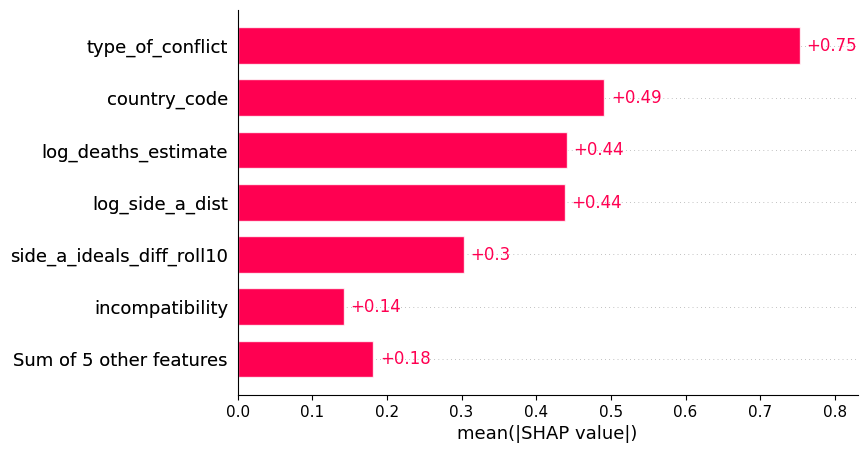

In [ ]:
# 2. Compute SHAP values natively inside XGBoost C++ core
# Convert X_test into DMatrix (handles categorical types automatically)
dtest = xgb.DMatrix(X_te, enable_categorical=True)

# pred_contribs=True returns SHAP matrix of shape (n_samples, n_features + 1)
shap_contribs = model.get_booster().predict(dtest, pred_contribs=True)

# Separate feature SHAP values from the base expected value (last column)
shap_values_matrix = shap_contribs[:, :-1]
base_value = shap_contribs[0, -1]

# 3. Create a SHAP Explanation object for rich plotting compatibility
explanation = shap.Explanation(
    values=shap_values_matrix,
    base_values=base_value,
    data=X_te,
    feature_names=feature_cols
)

# 4. Plot Global Importance Bar Chart (Top 5 + summary row)
plt.figure(figsize=(10, 6))

shap.plots.bar(
    explanation, 
    max_display=7  # Shows top 5 features + 1 summary bar for "+n other"
)

plt.show()

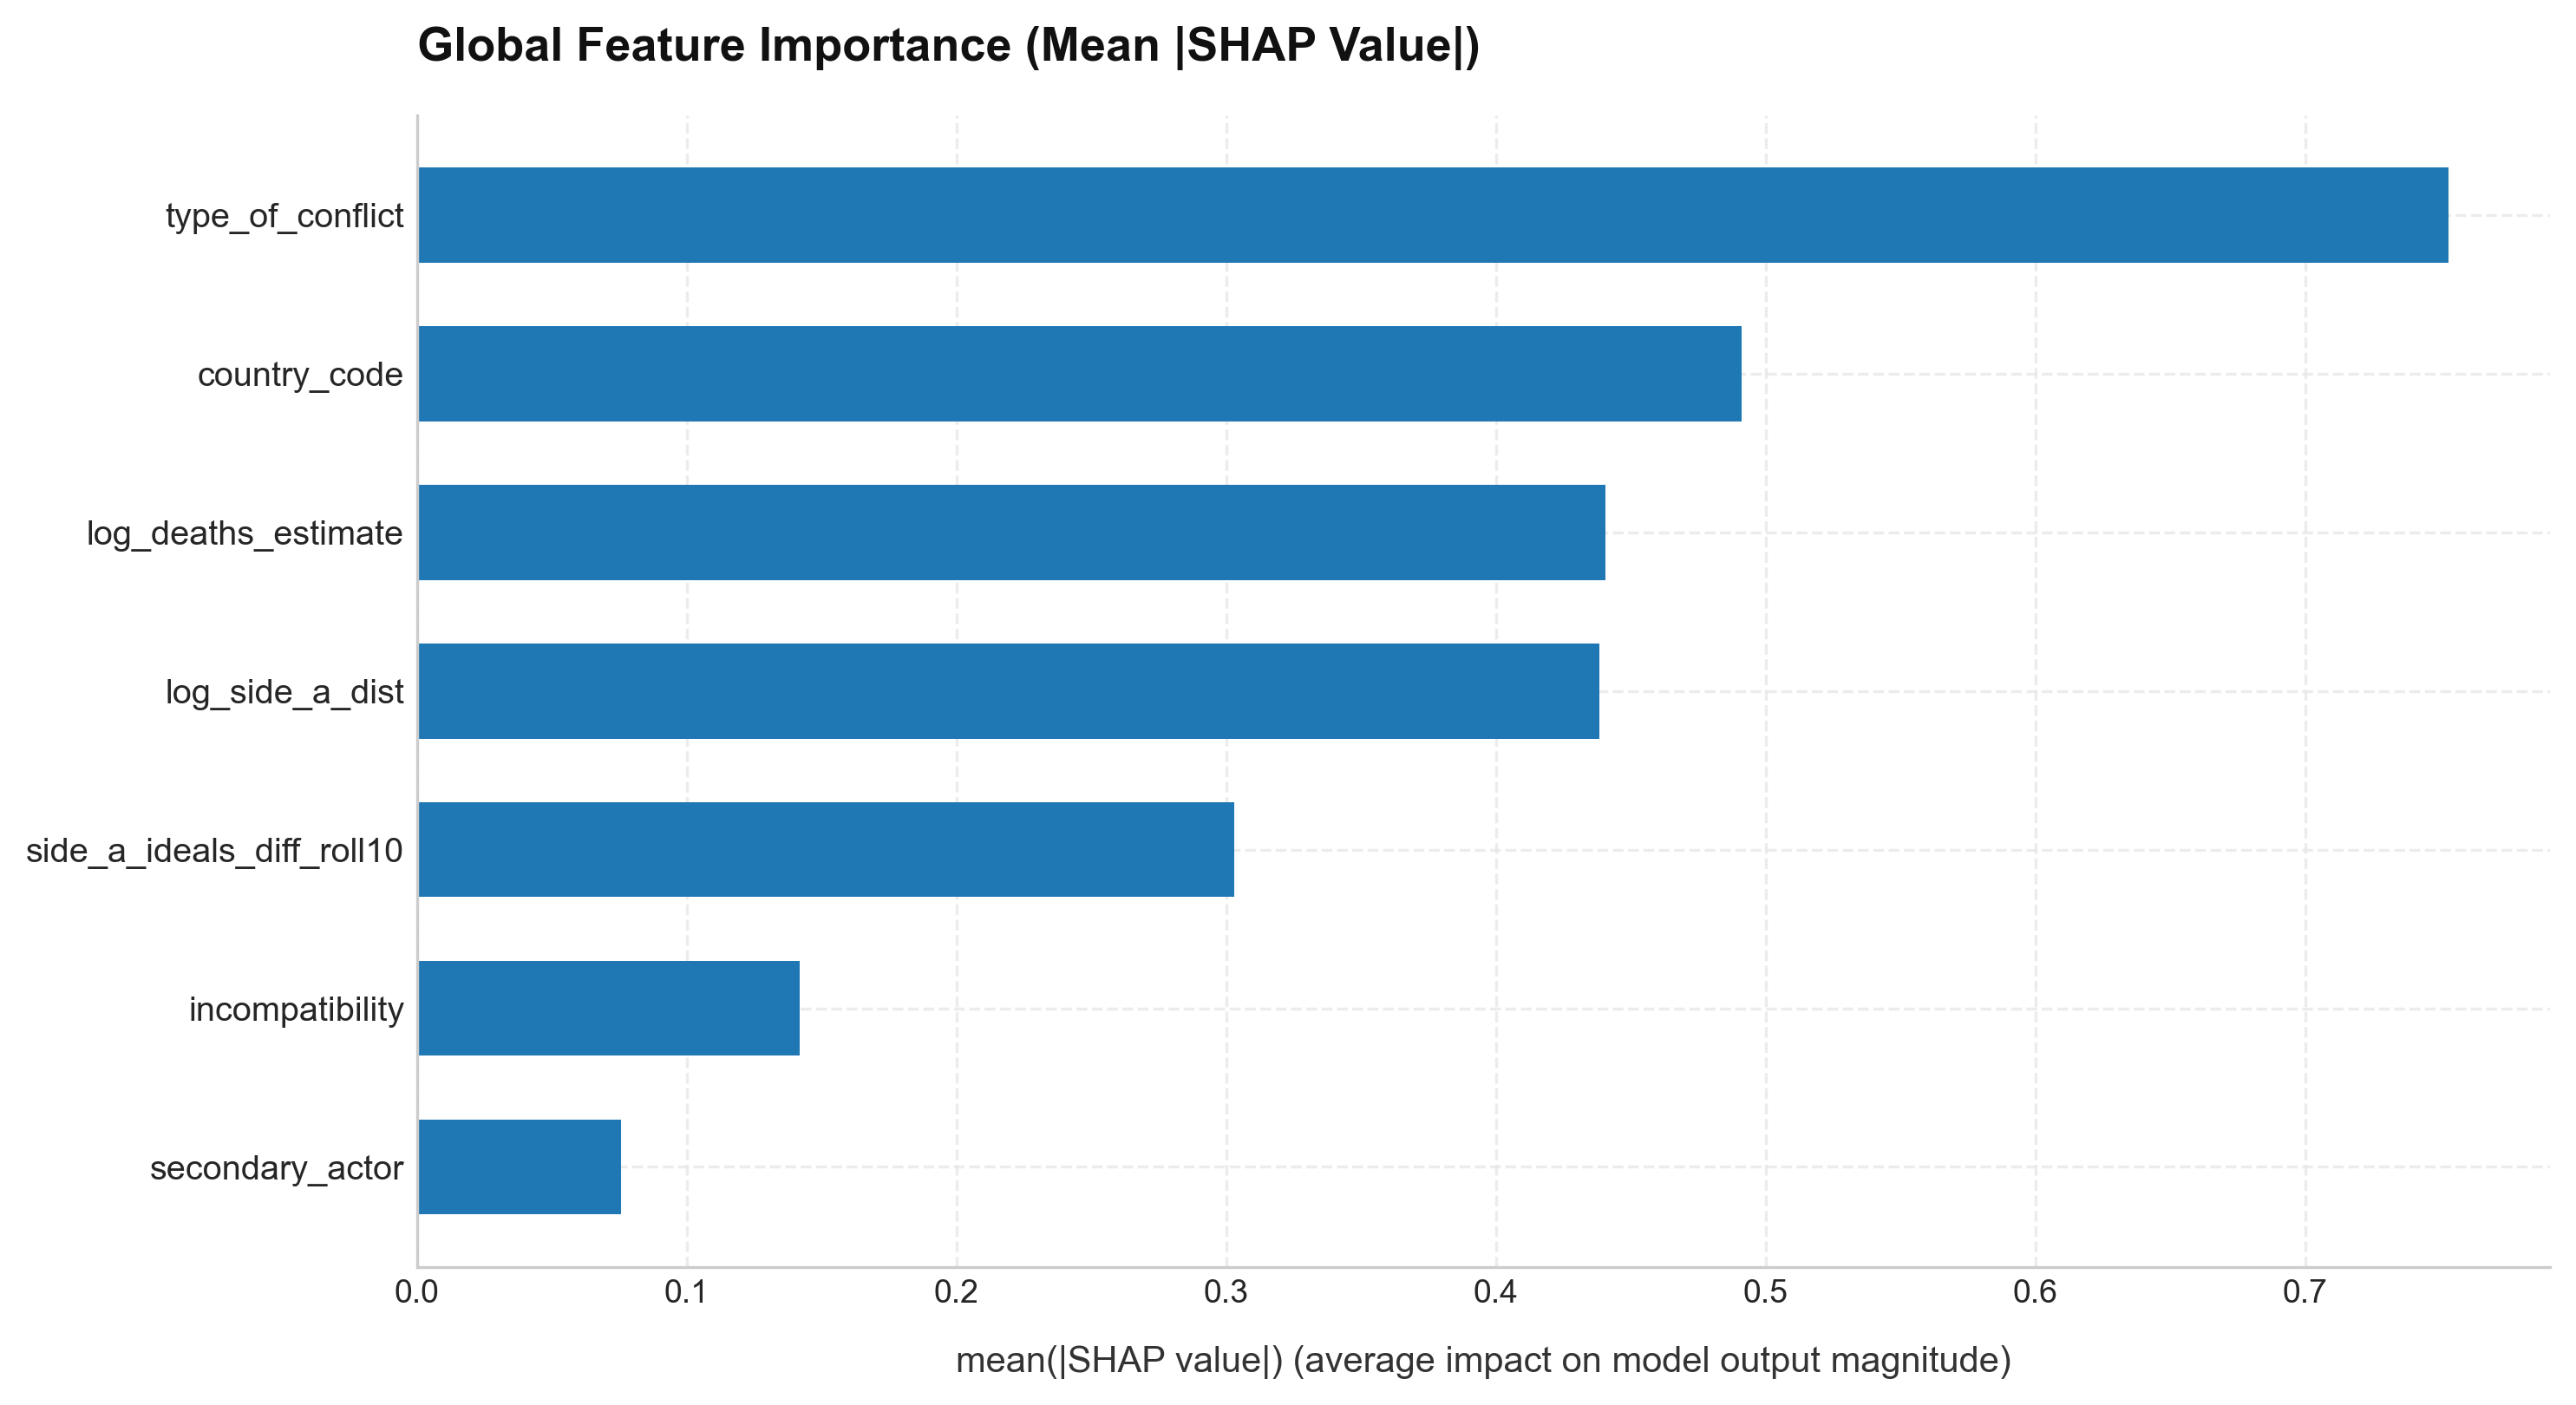

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

# 1. Apply sleek, modern plot styling
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Inter", "Helvetica Neue", "Arial"],
        "axes.edgecolor": "#CCCCCC",
        "axes.linewidth": 0.8,
        "grid.color": "#E5E5E5",
        "grid.linestyle": "--",
        "grid.alpha": 0.7,
        "figure.titlesize": 14,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9.5,
    }
)

# 2. Compute SHAP values via XGBoost C++ Booster core
dtest = xgb.DMatrix(X_te, enable_categorical=True)
shap_contribs = model.get_booster().predict(dtest, pred_contribs=True)
shap_values_matrix = shap_contribs[:, :-1]

# 3. Calculate Mean Absolute SHAP Values per Feature
mean_abs_shap = np.mean(np.abs(shap_values_matrix), axis=0)

# Create a DataFrame and sort for plotting top features
shap_df = pd.DataFrame(
    {"feature": feature_cols, "mean_abs_shap": mean_abs_shap}
).sort_values(
    by="mean_abs_shap", ascending=True
)  # Ascending so highest is at the top of barh

# Select top 7 features for display (similar to max_display=7)
shap_df_top = shap_df.tail(7)

# 4. Generate Publication-Quality Horizontal Bar Chart
fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)

bars = ax.barh(
    shap_df_top["feature"],
    shap_df_top["mean_abs_shap"],
    color="#1F77B4",
    height=0.6,
    edgecolor="none",
)

# 5. Visual Hierarchy Refinements
plt.title(
    "Global Feature Importance (Mean |SHAP Value|)",
    fontsize=13,
    fontweight="bold",
    pad=15,
    loc="left",
    color="#111111",
)
plt.xlabel(
    "mean(|SHAP value|) (average impact on model output magnitude)",
    fontsize=10,
    fontweight="medium",
    color="#333333",
    labelpad=10,
)

# Remove top and right spines
sns.despine(top=True, right=True, left=False, bottom=False)

# Ensure tight layout prevents text truncation
plt.tight_layout()
plt.show()

In [153]:
len(df)

438425

In [127]:
# Absolute counts of conflict mentions
year_df = df[df['year'] == 2022]
mention_counts = year_df['has_conflict_mention'].value_counts()

# Overall mention rate across all 330k rows
overall_rate = year_df['has_conflict_mention'].mean()

print("=== Entire Dataset Mention Summary ===")
print(f"Total Rows: {len(year_df):,}")
print(f"No Mention (0): {mention_counts.get(0, 0):,}")
print(f"Has Mention (1): {mention_counts.get(1, 0):,}")
print(f"Overall Mention Rate: {overall_rate:.4%}")

=== Entire Dataset Mention Summary ===
Total Rows: 9,727
No Mention (0): 7,899
Has Mention (1): 1,828
Overall Mention Rate: 18.7931%


In [128]:
len(df[df['has_conflict_mention'] == 1])/len(df)

0.16441253610839165

In [129]:
df['has_conflict_mention'].mean()

np.float64(0.16441253610839165)

NameError: name 'Y_te' is not defined

In [157]:
df.dtypes

country_code                 category
side_a                         object
conflict_id                     int64
year                            int64
has_conflict_mention            int64
intensity_level                 int64
cumulative_intensity            int64
type_of_conflict             category
main_actor                      int64
secondary_actor                 int64
conflict_host                   int64
incompatibility              category
location                       object
log_deaths_estimate           float64
log_side_a_dist               float64
side_a_ideals_diff_roll10     float64
dtype: object

In [158]:
import pandas as pd
import numpy as np

# 1. Define the Source Mapping Dictionary based on your data documentation
SOURCE_MAPPING = {
    'country_code': 'UNGDC',
    'side_a': 'UCDP/PRIO Armed Conflict Dataset',
    'conflict_id': 'UCDP/PRIO Armed Conflict Dataset',
    'year': 'UNGDC',
    'has_conflict_mention': 'UNGDC (Target Label)',
    'intensity_level': 'UCDP/PRIO Armed Conflict Dataset',
    'cumulative_intensity': 'UCDP/PRIO Armed Conflict Dataset',
    'type_of_conflict': 'UCDP/PRIO Armed Conflict Dataset',
    'main_actor': 'UCDP/PRIO Armed Conflict Dataset',
    'secondary_actor': 'UCDP/PRIO Armed Conflict Dataset',
    'conflict_host': 'UCDP/PRIO Armed Conflict Dataset',
    'incompatibility': 'UCDP/PRIO Armed Conflict Dataset',
    'location': 'UCDP/PRIO Armed Conflict Dataset',
    'log_deaths_estimate': 'Battle-Related Fatalities (UCDP/PRIO)',
    'log_side_a_dist': 'CEPII GeoDist',
    'side_a_ideals_diff_roll10': 'UNGA Voting Ideal Points'
}

# 2. Function to generate variable summary
def describe_dataset_variables(dataframe, source_map):
    summary_data = []
    
    for col in dataframe.columns:
        dtype = str(dataframe[col].dtype)
        pct_missing = (dataframe[col].isna().sum() / len(dataframe)) * 100
        n_unique = dataframe[col].nunique(dropna=True)
        source = source_map.get(col, 'Unknown')
        
        # Determine appropriate summary statistic (Mean/Std vs Most Frequent Category)
        if pd.api.types.is_numeric_dtype(dataframe[col]) and not pd.api.types.is_bool_dtype(dataframe[col]):
            # Check if it acts as a binary indicator (e.g., 0/1)
            if set(dataframe[col].dropna().unique()).issubset({0, 1}):
                pos_pct = (dataframe[col] == 1).mean() * 100
                stat_desc = f"Pos Rate: {pos_pct:.1f}%"
            else:
                mean_val = dataframe[col].mean()
                std_val = dataframe[col].std()
                min_val = dataframe[col].min()
                max_val = dataframe[col].max()
                stat_desc = f"Mean: {mean_val:.2f} (Std: {std_val:.2f}) [Range: {min_val:.1f} to {max_val:.1f}]"
        else:
            # For Categorical / Text variables
            top_val = dataframe[col].mode(dropna=True)
            top_val_str = str(top_val.iloc[0]) if not top_val.empty else "N/A"
            top_freq = dataframe[col].value_counts(dropna=True).iloc[0] if n_unique > 0 else 0
            top_pct = (top_freq / len(dataframe)) * 100
            stat_desc = f"Top: '{top_val_str}' ({top_pct:.1f}%)"
            
        summary_data.append({
            'Variable': col,
            'Data Type': dtype,
            'Source Dataset': source,
            '% Missing': f"{pct_missing:.2f}%",
            'Unique Values': n_unique,
            'Summary Statistics / Value Distribution': stat_desc
        })
        
    summary_df = pd.DataFrame(summary_data)
    return summary_df

# 3. Generate and Display Table
var_summary = describe_dataset_variables(df, SOURCE_MAPPING)

# Display full table without truncating text
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

print("=== DATASET VARIABLE DICTIONARY & SUMMARY ===")
print(var_summary.to_string(index=False))

=== DATASET VARIABLE DICTIONARY & SUMMARY ===
                 Variable Data Type                        Source Dataset % Missing  Unique Values                Summary Statistics / Value Distribution
             country_code  category                                 UNGDC     0.00%            200                                      Top: 'BLR' (0.6%)
                   side_a    object      UCDP/PRIO Armed Conflict Dataset     0.00%            121            Top: 'Government of Myanmar (Burma)' (9.4%)
              conflict_id     int64      UCDP/PRIO Armed Conflict Dataset     0.00%            303 Mean: 1964.78 (Std: 4386.76) [Range: 200.0 to 16470.0]
                     year     int64                                 UNGDC     0.00%             80   Mean: 1998.59 (Std: 18.78) [Range: 1946.0 to 2025.0]
     has_conflict_mention     int64                  UNGDC (Target Label)     0.00%              2                                        Pos Rate: 17.4%
          intensity_level     

In [ ]:
# # tuning
# import optuna
# import pandas as pd
# import numpy as np
# import xgboost as xgb
# from sklearn.metrics import average_precision_score

# # Silence Optuna logging verbosity if desired
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# def objective(trial):
#     # 1. Define Hyperparameter Search Space
#     params = {
#         'objective': 'binary:logistic',
#         'tree_method': 'hist',
#         'enable_categorical': True,
#         'random_state': 42,
        
#         # Hyperparameters to Tune
#         'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.10, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 8),
#         'subsample': trial.suggest_float('subsample', 0.5, 0.9),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
#         'gamma': trial.suggest_float('gamma', 0.0, 5.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
#     }
    
#     # Dynamic scale_pos_weight tuning multiplier (0.5x to 2.0x base ratio)
#     pos_weight_mult = trial.suggest_float('pos_weight_mult', 0.5, 2.0)

#     # 2. Walk-Forward Cross Validation within Objective
#     start_eval_year = 2012
#     end_eval_year = df['year'].max()
#     fold_pr_aucs = []

#     for test_year in range(start_eval_year, end_eval_year + 1):
#         train_mask = df['year'] < test_year
#         test_mask = df['year'] == test_year
        
#         train_df, test_df = df[train_mask], df[test_mask]
        
#         if len(test_df) == 0 or test_df[target_col].nunique() < 2:
#             continue
            
#         X_tr, y_tr = train_df[feature_cols], train_df[target_col]
#         X_te, y_te = test_df[feature_cols], test_df[target_col]
        
#         num_neg, num_pos = (y_tr == 0).sum(), (y_tr == 1).sum()
#         base_scale = (num_neg / num_pos) if num_pos > 0 else 1.0
        
#         # Apply model with candidate hyperparameters
#         model = xgb.XGBClassifier(
#             **params,
#             scale_pos_weight=base_scale * pos_weight_mult
#         )
        
#         model.fit(X_tr, y_tr, verbose=False)
        
#         probs = model.predict_proba(X_te)[:, 1]
#         pr_auc = average_precision_score(y_te, probs)
#         fold_pr_aucs.append(pr_auc)

#     # 3. Return Mean Out-of-Time PR-AUC
#     return np.mean(fold_pr_aucs)

# # 3. Execute Optimization Study
# print("Starting Optuna Hyperparameter Search...")
# study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
# study.optimize(objective, n_trials=30, timeout=1800, show_progress_bar=True)

# # 4. Results Summary
# print("\n=== Best Hyperparameters Found ===")
# print(f"Best Mean Walk-Forward PR-AUC: {study.best_value:.4f}")
# for key, value in study.best_params.items():
#     print(f"  {key}: {value}")

Starting Optuna Hyperparameter Search...


Best trial: 19. Best value: 0.566799:  67%|██████▋   | 20/30 [30:05<15:02, 90.28s/it, 1805.58/1800 seconds] 


=== Best Hyperparameters Found ===
Best Mean Walk-Forward PR-AUC: 0.5668
  n_estimators: 500
  learning_rate: 0.0573061611965527
  max_depth: 8
  subsample: 0.8600949656261856
  colsample_bytree: 0.8797494905618268
  min_child_weight: 10
  gamma: 0.5691416491676825
  reg_alpha: 0.004476605831100496
  reg_lambda: 0.05030190658480003
  pos_weight_mult: 0.7863821979648151
